# 09 — Validate Silhouette ↔ Skeleton Alignment

এই notebook existing skeleton files এবং newly extracted silhouette files match করবে।

Outputs:

```text
data/fusion_index/multimodal_index.csv
data/fusion_index/alignment_report.csv
data/fusion_splits/*_fusion.csv
```

Late/adaptive gated fusion-এর জন্য sample-level key alignment যথেষ্ট:

```text
subject + condition + seq + view
```

In [1]:
# ============================================================
# CELL 1 — Imports, paths, root detection
# ============================================================
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

EXP_DIR = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0")

POSE_TAG = None
SILHOUETTE_TAG = None

POSES_DIR = EXP_DIR / "data" / "poses"
SILHOUETTES_DIR = EXP_DIR / "data" / "silhouettes"

FUSION_INDEX_DIR = EXP_DIR / "data" / "fusion_index"
FUSION_SPLIT_DIR = EXP_DIR / "data" / "fusion_splits"
REPORT_DIR = EXP_DIR / "data" / "reports"

for d in [FUSION_INDEX_DIR, FUSION_SPLIT_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def detect_largest_child(root: Path, tag=None, suffix="*.npz"):
    if tag is not None:
        p = root / tag
        if not p.exists():
            raise FileNotFoundError(f"Requested folder does not exist: {p}")
        return p
    if not root.exists():
        raise FileNotFoundError(f"Root folder does not exist: {root}")
    candidates = [p for p in root.iterdir() if p.is_dir()]
    if not candidates:
        raise FileNotFoundError(f"No subfolders found under: {root}")
    counts = sorted([(len(list(p.rglob(suffix))), p) for p in candidates], reverse=True, key=lambda x: x[0])
    print("Candidate folders under", root)
    for count, p in counts:
        print(f"  {p.name}: {count} files")
    return counts[0][1]

POSE_ROOT = detect_largest_child(POSES_DIR, POSE_TAG)
SIL_ROOT = detect_largest_child(SILHOUETTES_DIR, SILHOUETTE_TAG)

print("=" * 80)
print("Fusion Alignment Validation")
print("POSE_ROOT:", POSE_ROOT)
print("SIL_ROOT :", SIL_ROOT)
print("=" * 80)

Candidate folders under /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/poses
  yolo26l_pose: 13640 files
Candidate folders under /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes
  yolo11m_seg_64x44: 13640 files
Fusion Alignment Validation
POSE_ROOT: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/poses/yolo26l_pose
SIL_ROOT : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/yolo11m_seg_64x44


In [2]:
# ============================================================
# CELL 2 — Build pose and silhouette indexes
# ============================================================
def record_from_modal_path(path: Path, root: Path, modal_name: str):
    rel = path.relative_to(root)
    if len(rel.parts) < 3:
        raise ValueError(f"Unexpected {modal_name} path: {path}")
    subject = str(rel.parts[0])
    condition_seq = str(rel.parts[1])
    view = str(path.stem)
    condition, seq = condition_seq.split("-", 1)
    return {
        "subject": subject, "condition": condition, "seq": seq, "view": view,
        f"{modal_name}_path": str(path),
        "key": f"{subject}-{condition}-{seq}-{view}",
    }

pose_files = sorted(POSE_ROOT.rglob("*.npz"))
sil_files = sorted(SIL_ROOT.rglob("*.npz"))

df_pose = pd.DataFrame([record_from_modal_path(p, POSE_ROOT, "pose") for p in pose_files])
df_sil = pd.DataFrame([record_from_modal_path(p, SIL_ROOT, "silhouette") for p in sil_files])

df_pose.to_csv(FUSION_INDEX_DIR / "pose_index.csv", index=False)
df_sil.to_csv(FUSION_INDEX_DIR / "silhouette_index.csv", index=False)

print("Pose files:", len(df_pose))
print("Sil files :", len(df_sil))
print("Expected  :", 124 * 10 * 11)
display(df_pose.head())
display(df_sil.head())

Pose files: 13640
Sil files : 13640
Expected  : 13640


,subject,condition,seq,view,pose_path,key
0,001,bg,01,000,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001-bg-01-000
1,001,bg,01,018,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001-bg-01-018
2,001,bg,01,036,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001-bg-01-036
3,001,bg,01,054,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001-bg-01-054
4,001,bg,01,072,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001-bg-01-072


,subject,condition,seq,view,silhouette_path,key
0,001,bg,01,000,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001-bg-01-000
1,001,bg,01,018,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001-bg-01-018
2,001,bg,01,036,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001-bg-01-036
3,001,bg,01,054,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001-bg-01-054
4,001,bg,01,072,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001-bg-01-072


In [3]:
# ============================================================
# CELL 3 — Match by sample key
# ============================================================
merge_keys = ["subject", "condition", "seq", "view", "key"]

df_all = pd.merge(df_pose, df_sil, on=merge_keys, how="outer", indicator=True)

df_matched = df_all[df_all["_merge"] == "both"].copy()
df_pose_only = df_all[df_all["_merge"] == "left_only"].copy()
df_sil_only = df_all[df_all["_merge"] == "right_only"].copy()

print("Matched      :", len(df_matched))
print("Pose only    :", len(df_pose_only))
print("Sil only     :", len(df_sil_only))
print("Expected full:", 124 * 10 * 11)

missing_report_csv = FUSION_INDEX_DIR / "missing_modalities_report.csv"
df_all.to_csv(missing_report_csv, index=False)
print("Saved:", missing_report_csv)

if len(df_pose_only):
    display(df_pose_only.head())
if len(df_sil_only):
    display(df_sil_only.head())

Matched      : 13640
Pose only    : 0
Sil only     : 0
Expected full: 13640
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_index/missing_modalities_report.csv


In [4]:
# ============================================================
# CELL 4 — Read metadata and frame counts
# ============================================================
def read_pose_meta(path):
    try:
        data = np.load(path)
        X = data["keypoints_norm_filled"]
        return {"T_pose": int(X.shape[0]), "pose_shape": str(tuple(X.shape)), "pose_error": ""}
    except Exception as e:
        return {"T_pose": 0, "pose_shape": "", "pose_error": str(e)}

def read_sil_meta(path):
    try:
        data = np.load(path)
        S = data["silhouettes"]
        T = int(S.shape[0])
        frame_valid = data["frame_valid"] if "frame_valid" in data.files else np.ones((T,), dtype=bool)
        det_scores = data["det_scores"] if "det_scores" in data.files else np.zeros((T,), dtype=np.float32)
        return {
            "T_silhouette": T,
            "silhouette_shape": str(tuple(S.shape)),
            "sil_valid_frame_ratio": float(frame_valid.mean()) if len(frame_valid) else 0.0,
            "sil_mean_det_score": float(np.nanmean(det_scores)) if len(det_scores) else 0.0,
            "silhouette_error": "",
        }
    except Exception as e:
        return {"T_silhouette": 0, "silhouette_shape": "", "sil_valid_frame_ratio": 0.0, "sil_mean_det_score": 0.0, "silhouette_error": str(e)}

rows = []

for _, row in tqdm(df_matched.iterrows(), total=len(df_matched), desc="Reading metadata"):
    pose_meta = read_pose_meta(row["pose_path"])
    sil_meta = read_sil_meta(row["silhouette_path"])
    T_pose = pose_meta["T_pose"]
    T_sil = sil_meta["T_silhouette"]
    T_common = min(T_pose, T_sil)
    T_diff = abs(T_pose - T_sil)

    if T_pose == 0 or T_sil == 0:
        status = "read_error"
    elif T_diff == 0:
        status = "exact"
    elif T_diff <= 2:
        status = "small_mismatch"
    else:
        status = "large_mismatch"

    rows.append({
        "key": row["key"], "subject": row["subject"], "condition": row["condition"], "seq": row["seq"], "view": row["view"],
        "pose_path": row["pose_path"], "silhouette_path": row["silhouette_path"],
        **pose_meta, **sil_meta,
        "T_common": T_common, "T_diff": T_diff, "alignment_status": status,
    })

df_align = pd.DataFrame(rows)
alignment_csv = FUSION_INDEX_DIR / "alignment_report.csv"
df_align.to_csv(alignment_csv, index=False)

print("Saved:", alignment_csv)
display(df_align["alignment_status"].value_counts())
display(df_align[["T_pose", "T_silhouette", "T_common", "T_diff", "sil_valid_frame_ratio", "sil_mean_det_score"]].describe())
display(df_align.head())

Reading metadata:   0%|          | 0/13640 [00:00<?, ?it/s]

Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_index/alignment_report.csv


alignment_status
exact    13640
Name: count, dtype: int64

,T_pose,T_silhouette,T_common,T_diff,sil_valid_frame_ratio,sil_mean_det_score
count,13640.000000,13640.000000,13640.000000,13640.0,13640.000000,13640.000000
mean,120.973974,120.973974,120.973974,0.0,0.848504,0.758749
std,21.729111,21.729111,21.729111,0.0,0.144987,0.136940
min,12.000000,12.000000,12.000000,0.0,0.000000,0.000000
25%,106.000000,106.000000,106.000000,0.0,0.722689,0.639307
50%,119.000000,119.000000,119.000000,0.0,0.877121,0.779515
75%,134.000000,134.000000,134.000000,0.0,1.000000,0.899471
max,311.000000,311.000000,311.000000,0.0,1.000000,0.939616


,key,subject,condition,seq,view,pose_path,silhouette_path,T_pose,pose_shape,pose_error,T_silhouette,silhouette_shape,sil_valid_frame_ratio,sil_mean_det_score,silhouette_error,T_common,T_diff,alignment_status
0,001-bg-01-000,001,bg,01,000,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,99,"(99, 17, 2)",,99,"(99, 64, 44)",1.000000,0.910541,,99,0,exact
1,001-bg-01-018,001,bg,01,018,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,102,"(102, 17, 2)",,102,"(102, 64, 44)",1.000000,0.905187,,102,0,exact
2,001-bg-01-036,001,bg,01,036,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,99,"(99, 17, 2)",,99,"(99, 64, 44)",0.969697,0.862985,,99,0,exact
3,001-bg-01-054,001,bg,01,054,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,106,"(106, 17, 2)",,106,"(106, 64, 44)",0.943396,0.839839,,106,0,exact
4,001-bg-01-072,001,bg,01,072,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,106,"(106, 17, 2)",,106,"(106, 64, 44)",0.811321,0.682147,,106,0,exact


In [5]:
# ============================================================
# CELL 5 — Create clean multimodal index
# ============================================================
SAFE_STATUSES = {"exact", "small_mismatch", "large_mismatch"}

df_multi = df_align[df_align["alignment_status"].isin(SAFE_STATUSES)].copy()
df_multi = df_multi[df_multi["T_common"] >= 20].copy()

multimodal_csv = FUSION_INDEX_DIR / "multimodal_index.csv"
df_multi.to_csv(multimodal_csv, index=False)

print("Usable multimodal samples:", len(df_multi))
print("Expected full CASIA-B   :", 124 * 10 * 11)
print("Saved:", multimodal_csv)
display(df_multi["alignment_status"].value_counts())
display(df_multi.head())

Usable multimodal samples: 13637
Expected full CASIA-B   : 13640
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_index/multimodal_index.csv


alignment_status
exact    13637
Name: count, dtype: int64

,key,subject,condition,seq,view,pose_path,silhouette_path,T_pose,pose_shape,pose_error,T_silhouette,silhouette_shape,sil_valid_frame_ratio,sil_mean_det_score,silhouette_error,T_common,T_diff,alignment_status
0,001-bg-01-000,001,bg,01,000,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,99,"(99, 17, 2)",,99,"(99, 64, 44)",1.000000,0.910541,,99,0,exact
1,001-bg-01-018,001,bg,01,018,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,102,"(102, 17, 2)",,102,"(102, 64, 44)",1.000000,0.905187,,102,0,exact
2,001-bg-01-036,001,bg,01,036,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,99,"(99, 17, 2)",,99,"(99, 64, 44)",0.969697,0.862985,,99,0,exact
3,001-bg-01-054,001,bg,01,054,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,106,"(106, 17, 2)",,106,"(106, 64, 44)",0.943396,0.839839,,106,0,exact
4,001-bg-01-072,001,bg,01,072,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,106,"(106, 17, 2)",,106,"(106, 64, 44)",0.811321,0.682147,,106,0,exact


In [6]:
# ============================================================
# CELL 6 — Create fusion split CSV files
# ============================================================
SPLIT_DIR = EXP_DIR / "data" / "splits"

split_files = [
    "train_ST.csv", "test_ST.csv", "gallery_ST.csv", "probe_ST_nm.csv", "probe_ST_bg.csv", "probe_ST_cl.csv",
    "train_MT.csv", "test_MT.csv", "gallery_MT.csv", "probe_MT_nm.csv", "probe_MT_bg.csv", "probe_MT_cl.csv",
    "train_LT.csv", "test_LT.csv", "gallery_LT.csv", "probe_LT_nm.csv", "probe_LT_bg.csv", "probe_LT_cl.csv",
]

csv_dtype = {"pose_path": str, "subject": str, "condition": str, "seq": str, "view": str}

df_lookup = df_multi[[
    "subject", "condition", "seq", "view",
    "pose_path", "silhouette_path",
    "T_pose", "T_silhouette", "T_common",
    "alignment_status", "sil_valid_frame_ratio", "sil_mean_det_score",
]].copy()

created = []

for filename in split_files:
    src = SPLIT_DIR / filename
    if not src.exists():
        print("[SKIP missing]", src)
        continue

    df_split = pd.read_csv(src, dtype=csv_dtype)
    df_fusion = pd.merge(
        df_split.drop(columns=["pose_path"], errors="ignore"),
        df_lookup,
        on=["subject", "condition", "seq", "view"],
        how="left",
        indicator=True,
    )

    missing = df_fusion[df_fusion["_merge"] != "both"].copy()
    df_fusion = df_fusion.drop(columns=["_merge"])

    out_name = filename.replace(".csv", "_fusion.csv")
    out_path = FUSION_SPLIT_DIR / out_name
    df_fusion.to_csv(out_path, index=False)
    created.append(out_path)

    print(f"{filename} -> {out_name}: rows={len(df_fusion)}, missing_multimodal={len(missing)}")

    if len(missing):
        miss_path = FUSION_SPLIT_DIR / filename.replace(".csv", "_missing_multimodal.csv")
        missing.to_csv(miss_path, index=False)
        print("  missing saved:", miss_path)

print("Created fusion split files:")
for p in created:
    print("-", p)

train_ST.csv -> train_ST_fusion.csv: rows=2640, missing_multimodal=0
test_ST.csv -> test_ST_fusion.csv: rows=11000, missing_multimodal=3
  missing saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/test_ST_missing_multimodal.csv
gallery_ST.csv -> gallery_ST_fusion.csv: rows=4400, missing_multimodal=3
  missing saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/gallery_ST_missing_multimodal.csv
probe_ST_nm.csv -> probe_ST_nm_fusion.csv: rows=2200, missing_multimodal=0
probe_ST_bg.csv -> probe_ST_bg_fusion.csv: rows=2200, missing_multimodal=0
probe_ST_cl.csv -> probe_ST_cl_fusion.csv: rows=2200, missing_multimodal=0
train_MT.csv -> train_MT_fusion.csv: rows=6820, missing_multimodal=0
test_MT.csv -> test_MT_fusion.csv: rows=6820, missing_multimodal=3
  missing saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/test_MT_missing_multimodal.csv
gallery_MT.csv -> gallery_MT_fusion.csv: rows=2728, missing_multimodal=3
  missing saved: 

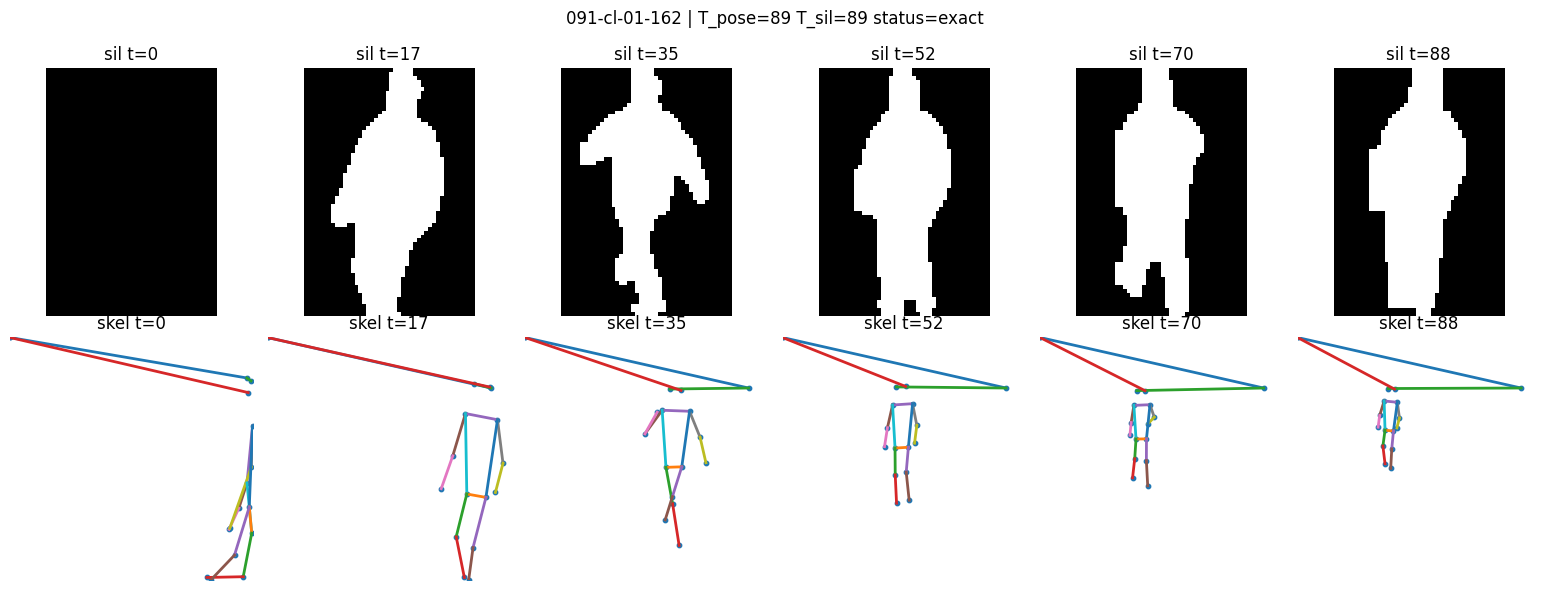

In [7]:
# ============================================================
# CELL 7 — Visual check
# ============================================================
COCO_EDGES = [
    (0, 1), (0, 2), (1, 3), (2, 4),
    (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
    (5, 11), (6, 12), (11, 12),
    (11, 13), (13, 15), (12, 14), (14, 16),
]

def plot_sample_alignment(row, num_frames=6):
    pose_data = np.load(row["pose_path"])
    sil_data = np.load(row["silhouette_path"])
    X = pose_data["keypoints_norm_filled"].astype(np.float32)
    S = sil_data["silhouettes"].astype(np.uint8)

    T = min(len(X), len(S))
    frame_ids = np.linspace(0, T - 1, num=min(num_frames, T)).astype(int)

    fig, axes = plt.subplots(2, len(frame_ids), figsize=(2.6 * len(frame_ids), 6))
    if len(frame_ids) == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for i, t in enumerate(frame_ids):
        ax0 = axes[0, i]
        ax0.imshow(S[t], cmap="gray")
        ax0.set_title(f"sil t={t}")
        ax0.axis("off")

        ax1 = axes[1, i]
        pts = X[t]
        for a, b in COCO_EDGES:
            ax1.plot([pts[a, 0], pts[b, 0]], [pts[a, 1], pts[b, 1]], linewidth=2)
        ax1.scatter(pts[:, 0], pts[:, 1], s=10)
        ax1.set_xlim(0, 1)
        ax1.set_ylim(1, 0)
        ax1.set_aspect("equal")
        ax1.set_title(f"skel t={t}")
        ax1.axis("off")

    fig.suptitle(f"{row['key']} | T_pose={row['T_pose']} T_sil={row['T_silhouette']} status={row['alignment_status']}")
    fig.tight_layout()
    plt.show()

if len(df_multi) == 0:
    print("No multimodal samples found.")
else:
    sample_row = df_multi.sample(1, random_state=42).iloc[0]
    plot_sample_alignment(sample_row)

In [8]:
# ============================================================
# CELL 8 — Fusion loader dry-run
# ============================================================
def crop_pair_for_fusion(pose_path, silhouette_path, seq_len=60, random_crop=True):
    pose_data = np.load(pose_path)
    sil_data = np.load(silhouette_path)

    X = pose_data["keypoints_norm_filled"].astype(np.float32)
    S = sil_data["silhouettes"].astype(np.uint8)

    T = min(len(X), len(S))
    if T <= 0:
        raise ValueError("Empty pose/silhouette sequence.")

    X = X[:T]
    S = S[:T]

    if T >= seq_len:
        start = np.random.randint(0, T - seq_len + 1) if random_crop else max(0, (T - seq_len) // 2)
        X_clip = X[start:start + seq_len]
        S_clip = S[start:start + seq_len]
    else:
        pad_len = seq_len - T
        X_clip = np.concatenate([X, np.repeat(X[-1:], pad_len, axis=0)], axis=0)
        S_clip = np.concatenate([S, np.repeat(S[-1:], pad_len, axis=0)], axis=0)

    return X_clip, S_clip

lt_train_fusion = FUSION_SPLIT_DIR / "train_LT_fusion.csv"

if lt_train_fusion.exists():
    df_train_fusion = pd.read_csv(lt_train_fusion, dtype=str)
    row = df_train_fusion.iloc[0]
    X_clip, S_clip = crop_pair_for_fusion(row["pose_path"], row["silhouette_path"], seq_len=60, random_crop=False)

    print("Fusion train rows:", len(df_train_fusion))
    print("X_clip shape:", X_clip.shape)
    print("S_clip shape:", S_clip.shape)
    print("Subject:", row["subject"], "Condition:", row["condition"], row["seq"], row["view"])

    assert X_clip.shape == (60, 17, 2)
    assert S_clip.shape[0] == 60
    print("[OK] Fusion loader dry-run passed.")
else:
    print("Missing:", lt_train_fusion)

Fusion train rows: 8140
X_clip shape: (60, 17, 2)
S_clip shape: (60, 64, 44)
Subject: 001 Condition: bg 01 000
[OK] Fusion loader dry-run passed.


In [9]:
# ============================================================
# CELL 9 — Final report
# ============================================================
report = {
    "pose_root": str(POSE_ROOT),
    "silhouette_root": str(SIL_ROOT),
    "num_pose_files": int(len(df_pose)),
    "num_silhouette_files": int(len(df_sil)),
    "num_matched": int(len(df_matched)),
    "num_multimodal_usable": int(len(df_multi)),
    "alignment_status_counts": df_align["alignment_status"].value_counts().to_dict(),
    "multimodal_index_csv": str(multimodal_csv),
    "alignment_report_csv": str(alignment_csv),
    "fusion_split_dir": str(FUSION_SPLIT_DIR),
}

report_path = FUSION_INDEX_DIR / "fusion_alignment_summary.json"
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print("=" * 80)
print("FUSION ALIGNMENT SUMMARY")
for k, v in report.items():
    print(k, ":", v)
print("=" * 80)
print("Saved:", report_path)

FUSION ALIGNMENT SUMMARY
pose_root : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/poses/yolo26l_pose
silhouette_root : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/yolo11m_seg_64x44
num_pose_files : 13640
num_silhouette_files : 13640
num_matched : 13640
num_multimodal_usable : 13637
alignment_status_counts : {'exact': 13640}
multimodal_index_csv : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_index/multimodal_index.csv
alignment_report_csv : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_index/alignment_report.csv
fusion_split_dir : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_index/fusion_alignment_summary.json


In [1]:
from pathlib import Path
import pandas as pd

EXP_DIR = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0")

SPLIT_DIR = EXP_DIR / "data" / "splits"
FUSION_INDEX_DIR = EXP_DIR / "data" / "fusion_index"
FUSION_SPLIT_DIR = EXP_DIR / "data" / "fusion_splits"
FUSION_SPLIT_DIR.mkdir(parents=True, exist_ok=True)

multimodal_csv = FUSION_INDEX_DIR / "multimodal_index.csv"
df_multi = pd.read_csv(multimodal_csv, dtype={
    "subject": str,
    "condition": str,
    "seq": str,
    "view": str,
    "pose_path": str,
    "silhouette_path": str,
})

split_files = [
    "train_ST.csv", "test_ST.csv", "gallery_ST.csv", "probe_ST_nm.csv", "probe_ST_bg.csv", "probe_ST_cl.csv",
    "train_MT.csv", "test_MT.csv", "gallery_MT.csv", "probe_MT_nm.csv", "probe_MT_bg.csv", "probe_MT_cl.csv",
    "train_LT.csv", "test_LT.csv", "gallery_LT.csv", "probe_LT_nm.csv", "probe_LT_bg.csv", "probe_LT_cl.csv",
]

csv_dtype = {
    "pose_path": str,
    "subject": str,
    "condition": str,
    "seq": str,
    "view": str,
}

lookup_cols = [
    "subject", "condition", "seq", "view",
    "pose_path", "silhouette_path",
    "T_pose", "T_silhouette", "T_common",
    "alignment_status", "sil_valid_frame_ratio", "sil_mean_det_score",
]

df_lookup = df_multi[lookup_cols].copy()

summary_rows = []

for filename in split_files:
    src = SPLIT_DIR / filename
    if not src.exists():
        print("[SKIP missing]", src)
        continue

    df_split = pd.read_csv(src, dtype=csv_dtype)

    df_merge = pd.merge(
        df_split.drop(columns=["pose_path"], errors="ignore"),
        df_lookup,
        on=["subject", "condition", "seq", "view"],
        how="left",
        indicator=True,
    )

    df_clean = df_merge[df_merge["_merge"] == "both"].drop(columns=["_merge"]).copy()
    df_missing = df_merge[df_merge["_merge"] != "both"].drop(columns=["_merge"]).copy()

    out_name = filename.replace(".csv", "_fusion.csv")
    out_path = FUSION_SPLIT_DIR / out_name
    df_clean.to_csv(out_path, index=False)

    missing_path = ""
    if len(df_missing) > 0:
        missing_path = FUSION_SPLIT_DIR / filename.replace(".csv", "_missing_multimodal.csv")
        df_missing.to_csv(missing_path, index=False)

    summary_rows.append({
        "source_split": filename,
        "source_rows": len(df_split),
        "fusion_rows_clean": len(df_clean),
        "missing_rows": len(df_missing),
        "out_csv": str(out_path),
        "missing_csv": str(missing_path),
    })

df_summary = pd.DataFrame(summary_rows)
summary_path = FUSION_SPLIT_DIR / "fusion_split_summary_clean.csv"
df_summary.to_csv(summary_path, index=False)

display(df_summary)
print("Saved clean split summary:", summary_path)

,source_split,source_rows,fusion_rows_clean,missing_rows,out_csv,missing_csv
0,train_ST.csv,2640,2640,0,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,
1,test_ST.csv,11000,10997,3,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
2,gallery_ST.csv,4400,4397,3,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
3,probe_ST_nm.csv,2200,2200,0,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,
4,probe_ST_bg.csv,2200,2200,0,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,
5,probe_ST_cl.csv,2200,2200,0,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,
6,train_MT.csv,6820,6820,0,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,
7,test_MT.csv,6820,6817,3,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
8,gallery_MT.csv,2728,2725,3,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
9,probe_MT_nm.csv,1364,1364,0,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,


Saved clean split summary: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/fusion_split_summary_clean.csv


In [2]:
from pathlib import Path
import pandas as pd

EXP_DIR = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0")
FUSION_SPLIT_DIR = EXP_DIR / "data" / "fusion_splits"

for name in [
    "gallery_LT_missing_multimodal.csv",
    "test_LT_missing_multimodal.csv",
]:
    p = FUSION_SPLIT_DIR / name
    if p.exists():
        print("\n", name)
        df = pd.read_csv(p, dtype=str)
        display(df[["subject", "condition", "seq", "view", "pose_path", "silhouette_path", "T_common"]])


 gallery_LT_missing_multimodal.csv


,subject,condition,seq,view,pose_path,silhouette_path,T_common
0,109,nm,01,126,NaN,NaN,NaN
1,109,nm,01,144,NaN,NaN,NaN
2,109,nm,01,162,NaN,NaN,NaN



 test_LT_missing_multimodal.csv


,subject,condition,seq,view,pose_path,silhouette_path,T_common
0,109,nm,01,126,NaN,NaN,NaN
1,109,nm,01,144,NaN,NaN,NaN
2,109,nm,01,162,NaN,NaN,NaN


In [3]:
from pathlib import Path
import pandas as pd

EXP_DIR = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0")
FUSION_INDEX_DIR = EXP_DIR / "data" / "fusion_index"
REPORT_DIR = EXP_DIR / "data" / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

df_align = pd.read_csv(FUSION_INDEX_DIR / "alignment_report.csv", dtype={
    "subject": str,
    "condition": str,
    "seq": str,
    "view": str,
})

low_quality = df_align[
    (pd.to_numeric(df_align["sil_valid_frame_ratio"], errors="coerce") < 0.50) |
    (pd.to_numeric(df_align["sil_mean_det_score"], errors="coerce") < 0.25)
].copy()

low_quality_csv = REPORT_DIR / "yolo_silhouette_low_quality_alignment_samples.csv"
low_quality.to_csv(low_quality_csv, index=False)

print("Low-quality samples:", len(low_quality))
print("Saved:", low_quality_csv)

display(
    low_quality[
        ["key", "subject", "condition", "seq", "view", "T_common",
         "sil_valid_frame_ratio", "sil_mean_det_score", "silhouette_path"]
    ].head(50)
)

Low-quality samples: 96
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/reports/yolo_silhouette_low_quality_alignment_samples.csv


,key,subject,condition,seq,view,T_common,sil_valid_frame_ratio,sil_mean_det_score,silhouette_path
370,004-cl-02-126,004,cl,02,126,87,0.459770,0.414680,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
444,005-bg-01-072,005,bg,01,072,187,0.481283,0.403222,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
445,005-bg-01-090,005,bg,01,090,186,0.467742,0.389008,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
446,005-bg-01-108,005,bg,01,108,180,0.494444,0.408400,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
466,005-cl-01-072,005,cl,01,072,202,0.405941,0.347353,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
467,005-cl-01-090,005,cl,01,090,206,0.417476,0.344273,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
468,005-cl-01-108,005,cl,01,108,198,0.424242,0.365331,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
469,005-cl-01-126,005,cl,01,126,206,0.446602,0.395145,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
470,005-cl-01-144,005,cl,01,144,210,0.438095,0.371849,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...
477,005-cl-02-072,005,cl,02,072,204,0.416667,0.354400,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...


In [4]:
from pathlib import Path

SIL_ROOT = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0/data/silhouettes/yolo11m_seg_64x44")
sil_files = sorted(SIL_ROOT.rglob("*.npz"))

print("Total YOLO silhouette files:", len(sil_files))
print("Expected:", 13640)

Total YOLO silhouette files: 13640
Expected: 13640
